# CRISP-DM Methodolgy For jumia Data scraped on (4/12/2025)

#### 1- Business understanding 
The goal of this project is to analyze 10 categories of products data scraped from jumia on (29/11/2025)
we aim to understad  pricing patterns, product availability, rating, and other key factors that can support:
 - Market anlysis
 - Price comparsion 
 - Identifying top categories 
 - Understnding customer perferences 
 - Detecting data quality issues 
This step defines why are doing the analysis and what business desicions could be supported by the data

#### 2- Data collecting  
- In this stage we scraped our data project using BeautifulSoup library from jumia website 

In [88]:
!pip install matplotlib
!pip install scikit-learn
!pip install seaborn


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


   ---------------------------------------- 0.0/8.7 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.7 MB 3.9 MB/s eta 0:00:03
   ---- ----------------------------------- 1.0/8.7 MB 2.4 MB/s eta 0:00:04
   -------- ------------------------------- 1.8/8.7 MB 3.4 MB/s eta 0:00:03
   ------------- -------------------------- 2.9/8.7 MB 3.8 MB/s eta 0:00:02
   ------------------ --------------------- 3.9/8.7 MB 3.8 MB/s eta 0:00:02
   --------------------- ------------------ 4.7/8.7 MB 3.8 MB/s eta 0:00:02
   ------------------------- -------------- 5.5/8.7 MB 3.8 MB/s eta 0:00:01
   --------------------------- ------------ 6.0/8.7 MB 3.8 MB/s eta 0:00:01
   --------------------------- ------------ 6.0/8.7 MB 3.8 MB/s eta 0:00:01
   --------------------------- ------------ 6.0/8.7 MB 3.8 MB/s eta 0:00:01
   --------------------------- ------------ 6.0/8.7 MB 3.8 MB/s eta 0:00:01
   --------------------------- ------------ 6.0/8.7 MB 3.8 MB/s eta 0:00:01
   ----------------


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [93]:
import requests
from bs4 import BeautifulSoup
import csv
import time
import pandas as pd 
import matplotlib.pyplot as plot
import seaborn as sn
import pandas as pd 
import sklearn 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score



In [11]:
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/115.0.0.0 Safari/537.36"
}

categories = ["phones", "toys", "cameras","baby%20products","health&beauty","sports%20wear","fashion","games"]
all_products = []


In [12]:




for category in categories:
    print(f"\n---  {category.upper()} ---") 
    
    base_url = f"https://www.jumia.com.eg/catalog/?q={category}"

    for page in range(1, 25):
        url = f"{base_url}&page={page}"
        
        try:
            response = requests.get(url, headers=headers, timeout=10)
            print(f"Status: {response.status_code} | category: {category} | page: {page}")
            
            if response.status_code != 200:
                print(f"An error in page: {page} with the status code: {response.status_code}")
                break
        

        except requests.exceptions.RequestException as e:
            print(f"An error in page: {page} in category {category}: {e}")
            break
        

        soup = BeautifulSoup(response.text, "html.parser")
        products = soup.find_all("article", {"class": lambda x: x and "prd" in x})

        for p in products:
            name = p.find("h3")
            price = p.find("div", {"class": "prc"})
            oldPrice=p.find("div",{"class":"old"})
            rate=p.find("div",{"class":"stars_s"})
            numOfVotes=p.find("div",{"class":"rev"})
            discount = p.find("div", {"class": "bdg _dsct _sm"})
        
            name_text = name.text.strip() if name else None
            price_text = price.text.strip() if price else None
            oldPrice_text = oldPrice.text.strip() if oldPrice else None
            discount_text=discount.text.strip() if discount else "0%"
            rate_text = None 
            total_text = None
            
            if rate:
                parts = rate.text.strip().split()
                if len(parts) >= 3:
                    rate_text = parts[0]                 
                    total_text = parts[-1] 
                    
            numOfVotes_text = numOfVotes.text.strip() if numOfVotes else None 

            all_products.append({
                "category": category,
                "name": name_text,
                "price": price_text,
                "oldPrice": oldPrice_text,
                "discount":discount_text,
                "rate": rate_text,
                "total": total_text,
                "numOfVotes": numOfVotes_text,
            })

        time.sleep(2)

keys = ["category","name", "price","oldPrice","discount","rate","total","numOfVotes"]
with open("jumia_multi_categories.csv", "w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=keys)
    writer.writeheader()
    writer.writerows(all_products)


---  PHONES ---
Status: 200 | category: phones | page: 1
Status: 200 | category: phones | page: 2
Status: 200 | category: phones | page: 3
Status: 200 | category: phones | page: 4
Status: 200 | category: phones | page: 5
Status: 200 | category: phones | page: 6
Status: 200 | category: phones | page: 7
Status: 200 | category: phones | page: 8
Status: 200 | category: phones | page: 9
Status: 200 | category: phones | page: 10
Status: 200 | category: phones | page: 11
Status: 200 | category: phones | page: 12
Status: 200 | category: phones | page: 13
Status: 200 | category: phones | page: 14
Status: 200 | category: phones | page: 15
Status: 200 | category: phones | page: 16
Status: 200 | category: phones | page: 17
Status: 200 | category: phones | page: 18
Status: 200 | category: phones | page: 19
Status: 200 | category: phones | page: 20
Status: 200 | category: phones | page: 21
Status: 200 | category: phones | page: 22
Status: 200 | category: phones | page: 23
Status: 200 | category: ph

Reading Data

In [96]:
df=pd.read_csv("jumia_multi_categories.csv")

Data Cleaning & Inspection

 Data Inspection

In [97]:
print("====== Information about Data ======")
df.info()

====== Information about Data ======
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7680 entries, 0 to 7679
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   category    7680 non-null   object 
 1   name        7680 non-null   object 
 2   price       7680 non-null   object 
 3   oldPrice    4681 non-null   object 
 4   discount    7680 non-null   object 
 5   rate        0 non-null      float64
 6   total       0 non-null      float64
 7   numOfVotes  2851 non-null   object 
dtypes: float64(2), object(6)
memory usage: 480.1+ KB


In [98]:
print("====== First 5 Rows before Cleaning ======")
df.head(5)

====== First 5 Rows before Cleaning ======


,category,name,price,oldPrice,discount,rate,total,numOfVotes
0,phones,OPPO A5 Dual SIM 4G 256GB/8GB - Aurora Green,"EGP 9,499.00","EGP 10,888.90",13%,NaN,NaN,4.5 out of 5(2)
1,phones,"Infinix XPAD 20 11.0"" Inch Single SIM 4G 128GB...","EGP 7,099.00","EGP 7,999.00",11%,NaN,NaN,NaN
2,phones,"OPPO A5X Dual SIM, 128GB, 4GB RAM, 4G LTE - La...","EGP 7,589.00","EGP 8,730.00",13%,NaN,NaN,NaN
3,phones,Honor 400 Lite Dual SIM 5G 256GB/8GB - Velvet ...,"EGP 12,099.00","EGP 13,405.91",10%,NaN,NaN,3.9 out of 5(9)
4,phones,Honor X5c Plus Dual SIM 4G 128GB/4GB - Midnigh...,"EGP 4,399.00","EGP 5,150.25",15%,NaN,NaN,NaN


In [99]:
print("====== Sample of Data before Cleaning ======")
df.sample(5)

====== Sample of Data before Cleaning ======


,category,name,price,oldPrice,discount,rate,total,numOfVotes
3785,baby%20products,"Silicone Baby Fruit Pacifier, 2724569387140",EGP 90.00,NaN,0%,NaN,NaN,5 out of 5(1)
4078,health&beauty,Dozova MAN MAX 30 CAP,EGP 255.00,EGP 390.00,35%,NaN,NaN,5 out of 5(1)
5309,sports%20wear,Decathlon High Sports Socks RS 160 Tri-Pack - ...,EGP 379.00,NaN,0%,NaN,NaN,NaN
5171,sports%20wear,Nike M Nsw Tee M90 Oc Pk 2 Sportswear Tops,"EGP 2,606.00","EGP 3,069.00",15%,NaN,NaN,5 out of 5(1)
2271,cameras,Hikvision DS-2CE76D0T-EXIPF Indoor Security Ca...,EGP 679.00,EGP 900.00,25%,NaN,NaN,NaN


In [100]:
print("====== Last 5 Rows before cleaning")
df.tail(5)

====== Last 5 Rows before cleaning


,category,name,price,oldPrice,discount,rate,total,numOfVotes
7675,games,Bandai Namco Elden Ring - PS4,"EGP 2,029.00",NaN,0%,NaN,NaN,NaN
7676,games,aurs Racing Track - Multicolor Interactive Pla...,EGP 495.00,NaN,0%,NaN,NaN,NaN
7677,games,Dining Table for Interactive Learning and Fun,EGP 875.00,NaN,0%,NaN,NaN,NaN
7678,games,Warner Bros. Interactive LEGO Marvel Super Her...,"EGP 1,139.00",NaN,0%,NaN,NaN,NaN
7679,games,Warner Bros. Interactive Lego Marvel Collectio...,"EGP 1,585.00",NaN,0%,NaN,NaN,NaN


In [101]:
print("====check null====")
df.isnull()

====check null====


,category,name,price,oldPrice,discount,rate,total,numOfVotes
0,False,False,False,False,False,True,True,False
1,False,False,False,False,False,True,True,True
2,False,False,False,False,False,True,True,True
3,False,False,False,False,False,True,True,False
4,False,False,False,False,False,True,True,True
...,...,...,...,...,...,...,...,...
7675,False,False,False,True,False,True,True,True
7676,False,False,False,True,False,True,True,True
7677,False,False,False,True,False,True,True,True
7678,False,False,False,True,False,True,True,True


In [102]:
print("===count nulls ===")
df.isnull().sum()

===count nulls ===


category         0
name             0
price            0
oldPrice      2999
discount         0
rate          7680
total         7680
numOfVotes    4829
dtype: int64

In [103]:
print("====check duplicates=====")
df.duplicated()

====check duplicates=====


0       False
1       False
2       False
3       False
4       False
        ...  
7675    False
7676    False
7677    False
7678    False
7679    False
Length: 7680, dtype: bool

In [104]:
print("====count duplicate====")
df.duplicated().sum()

====count duplicate====


np.int64(329)

In [105]:
print("====drop duplicate====")
df = df.drop_duplicates()

====drop duplicate====


In [106]:
print("====count duplicate after drop duplicate====")
df.duplicated().sum()

====count duplicate after drop duplicate====


np.int64(0)

#### 3- prepration and Cleaning Data

drop column total

In [107]:

df=df.drop(columns=['total'])

 #### Replace all NaN values in the 'numOfVotes' column with an empty string

In [108]:

df['numOfVotes']=df['numOfVotes'].fillna("")

#### Extract the numeric rating

In [109]:

df['rate']=df['numOfVotes'].str.extract(r"(\d+\.?\d*)\s*out of ",expand=False)

#### Extract the number of votes inside parentheses 

In [110]:

df['numOfVotes']=df['numOfVotes'].str.extract(r"\((\d+)\)",expand=False)

#### Convert the 'rate' column to numeric values; invalid entries become NaN
Convert the 'numOfVotes' column to numeric values; invalid entries become NaN


In [111]:

df['rate']=pd.to_numeric(df['rate'],errors="coerce")
df['numOfVotes']=pd.to_numeric(df['numOfVotes'],errors="coerce")


 #### Replace NaN values in the 'rate' column with -1

In [112]:

df['rate']=df['rate'].fillna(-1)


 #### Replace NaN values in the 'numOfvotes' column with 0

In [113]:

df['numOfVotes']=df['numOfVotes'].fillna(0)

#### Remove % and convert to numeric
Convert to float

In [114]:

df['discount'] = df['discount'].str.replace('%', '', regex=False)

df['discount'] = pd.to_numeric(df['discount'], errors='coerce')

df['discount'].head()

0    13
1    11
2    13
3    10
4    15
Name: discount, dtype: int64

In [115]:
df.head(5)

,category,name,price,oldPrice,discount,rate,numOfVotes
0,phones,OPPO A5 Dual SIM 4G 256GB/8GB - Aurora Green,"EGP 9,499.00","EGP 10,888.90",13,4.5,2.0
1,phones,"Infinix XPAD 20 11.0"" Inch Single SIM 4G 128GB...","EGP 7,099.00","EGP 7,999.00",11,-1.0,0.0
2,phones,"OPPO A5X Dual SIM, 128GB, 4GB RAM, 4G LTE - La...","EGP 7,589.00","EGP 8,730.00",13,-1.0,0.0
3,phones,Honor 400 Lite Dual SIM 5G 256GB/8GB - Velvet ...,"EGP 12,099.00","EGP 13,405.91",10,3.9,9.0
4,phones,Honor X5c Plus Dual SIM 4G 128GB/4GB - Midnigh...,"EGP 4,399.00","EGP 5,150.25",15,-1.0,0.0


In [116]:
df['rate']

0       4.5
1      -1.0
2      -1.0
3       3.9
4      -1.0
       ... 
7675   -1.0
7676   -1.0
7677   -1.0
7678   -1.0
7679   -1.0
Name: rate, Length: 7351, dtype: float64

In [117]:
df.sample(5)

,category,name,price,oldPrice,discount,rate,numOfVotes
203,phones,Vivo V60 Dual SIM 256GB 12GB RAM 5G - Gold,"EGP 23,899.00","EGP 33,333.00",28,1.0,1.0
1588,toys,Taste Kitchen Playset for Kids - Interactive C...,EGP 650.00,NaN,0,-1.0,0.0
444,phones,Apple iPhone 16e 128GB Black Tax Paid Warranty...,"EGP 39,900.00",NaN,0,-1.0,0.0
5254,sports%20wear,Nileton Sportswear - Sport Top Long Sleeves – ...,EGP 365.00,EGP 750.00,51,4.4,25.0
2557,cameras,Samsung Galaxy S23 Ultra Camera Lens Protector...,EGP 130.00,EGP 250.00,48,-1.0,0.0


In [118]:
df.tail(5)

,category,name,price,oldPrice,discount,rate,numOfVotes
7675,games,Bandai Namco Elden Ring - PS4,"EGP 2,029.00",NaN,0,-1.0,0.0
7676,games,aurs Racing Track - Multicolor Interactive Pla...,EGP 495.00,NaN,0,-1.0,0.0
7677,games,Dining Table for Interactive Learning and Fun,EGP 875.00,NaN,0,-1.0,0.0
7678,games,Warner Bros. Interactive LEGO Marvel Super Her...,"EGP 1,139.00",NaN,0,-1.0,0.0
7679,games,Warner Bros. Interactive Lego Marvel Collectio...,"EGP 1,585.00",NaN,0,-1.0,0.0


#### Clean the 'price' column by:
 - Converting values to string
- Removing "EGP"
 - Removing commas
 - Removing the string "nan"
 - Stripping extra spaces



In [119]:


df['price'] = (
    df['price']
    .astype(str)
    .str.replace("EGP", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.replace("nan", "", regex=False)
    .str.strip()
)

df['price'] = pd.to_numeric(df['price'], errors='coerce')


df['price'] = df['price'].fillna(0)



 #### Clean the 'oldPrice' column by:
 - Converting values to string
- Removing "EGP"
 - Removing commas
 - Removing the string "nan"
 Stripping extra spaces
 Replace NaN with -1

In [120]:

df['oldPrice'] = (
    df['oldPrice']
    .astype(str)
    .str.replace("EGP", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.replace("nan", "", regex=False)
    .str.strip()
)

df['oldPrice'] = pd.to_numeric(df['oldPrice'], errors='coerce')


df['oldPrice'] = df['oldPrice'].fillna(-1)

df.head()

,category,name,price,oldPrice,discount,rate,numOfVotes
0,phones,OPPO A5 Dual SIM 4G 256GB/8GB - Aurora Green,9499.0,10888.90,13,4.5,2.0
1,phones,"Infinix XPAD 20 11.0"" Inch Single SIM 4G 128GB...",7099.0,7999.00,11,-1.0,0.0
2,phones,"OPPO A5X Dual SIM, 128GB, 4GB RAM, 4G LTE - La...",7589.0,8730.00,13,-1.0,0.0
3,phones,Honor 400 Lite Dual SIM 5G 256GB/8GB - Velvet ...,12099.0,13405.91,10,3.9,9.0
4,phones,Honor X5c Plus Dual SIM 4G 128GB/4GB - Midnigh...,4399.0,5150.25,15,-1.0,0.0


Clean the product name by:
 - Converting values to string
 - Replacing "–" with a normal hyphen "-"
 - Replacing multiple spaces with a single space
 - Removing leading and trailing spaces


In [121]:


df['name_clean'] = (
    df['name']
    .astype(str)
    .str.replace("–", "-", regex=False)  
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
)


df['brand'] = df['name_clean'].str.split().str[0]


df['model'] = df['name_clean'].str.split().str[1]




In [122]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7351 entries, 0 to 7679
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   category    7351 non-null   object 
 1   name        7351 non-null   object 
 2   price       7351 non-null   float64
 3   oldPrice    7351 non-null   float64
 4   discount    7351 non-null   int64  
 5   rate        7351 non-null   float64
 6   numOfVotes  7351 non-null   float64
 7   name_clean  7351 non-null   object 
 8   brand       7351 non-null   object 
 9   model       7338 non-null   object 
dtypes: float64(4), int64(1), object(5)
memory usage: 631.7+ KB


#### Replace NaN values in the 'model' column with the string "No Model"

In [123]:

df['model'] = df['model'].fillna('No Model')

In [124]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7351 entries, 0 to 7679
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   category    7351 non-null   object 
 1   name        7351 non-null   object 
 2   price       7351 non-null   float64
 3   oldPrice    7351 non-null   float64
 4   discount    7351 non-null   int64  
 5   rate        7351 non-null   float64
 6   numOfVotes  7351 non-null   float64
 7   name_clean  7351 non-null   object 
 8   brand       7351 non-null   object 
 9   model       7351 non-null   object 
dtypes: float64(4), int64(1), object(5)
memory usage: 631.7+ KB


#### Clean the 'category' column by:
 - Converting values to string
 - Replacing any non-letter characters with a space
 - Replacing multiple spaces with a single space
 - Removing leading and trailing spaces


In [125]:

df['category_clean'] = (
    df['category']
    .astype(str)
    .str.replace(r'[^A-Za-z]', ' ', regex=True) 
    .str.replace(r'\s+', ' ', regex=True)        
    .str.strip()                     
)

Data Inspection After Cleaning

In [126]:
print("====== Data Shape ======")
df.shape

====== Data Shape ======


(7351, 11)

In [127]:
print("====== First 5 Rows ======")
df.head(5)

====== First 5 Rows ======


,category,name,price,oldPrice,discount,rate,numOfVotes,name_clean,brand,model,category_clean
0,phones,OPPO A5 Dual SIM 4G 256GB/8GB - Aurora Green,9499.0,10888.90,13,4.5,2.0,OPPO A5 Dual SIM 4G 256GB/8GB - Aurora Green,OPPO,A5,phones
1,phones,"Infinix XPAD 20 11.0"" Inch Single SIM 4G 128GB...",7099.0,7999.00,11,-1.0,0.0,"Infinix XPAD 20 11.0"" Inch Single SIM 4G 128GB...",Infinix,XPAD,phones
2,phones,"OPPO A5X Dual SIM, 128GB, 4GB RAM, 4G LTE - La...",7589.0,8730.00,13,-1.0,0.0,"OPPO A5X Dual SIM, 128GB, 4GB RAM, 4G LTE - La...",OPPO,A5X,phones
3,phones,Honor 400 Lite Dual SIM 5G 256GB/8GB - Velvet ...,12099.0,13405.91,10,3.9,9.0,Honor 400 Lite Dual SIM 5G 256GB/8GB - Velvet ...,Honor,400,phones
4,phones,Honor X5c Plus Dual SIM 4G 128GB/4GB - Midnigh...,4399.0,5150.25,15,-1.0,0.0,Honor X5c Plus Dual SIM 4G 128GB/4GB - Midnigh...,Honor,X5c,phones


In [128]:
print("====== Random Sample of Data after Cleaning ======")
df.sample(5)

====== Random Sample of Data after Cleaning ======


,category,name,price,oldPrice,discount,rate,numOfVotes,name_clean,brand,model,category_clean
223,phones,Apple iPhone 15 128GB Blue Tax Paid warranty 2...,47700.00,-1.0,0,-1.0,0.0,Apple iPhone 15 128GB Blue Tax Paid warranty 2...,Apple,iPhone,phones
4805,sports%20wear,Nike M Nkct Df Advtg Top Print - Men's Sports Top,4723.00,5559.0,15,-1.0,0.0,Nike M Nkct Df Advtg Top Print - Men's Sports Top,Nike,M,sports wear
4971,sports%20wear,LC Waikiki Patterned Girl Booties Socks 5-Pack,109.00,229.0,52,2.5,2.0,LC Waikiki Patterned Girl Booties Socks 5-Pack,LC,Waikiki,sports wear
7181,games,Fun Kitchen Rice Cooker & Fridge,163.75,200.0,18,-1.0,0.0,Fun Kitchen Rice Cooker & Fridge,Fun,Kitchen,games
5260,sports%20wear,Nike W Nsw Tee Essntl Lbr Sportswear Tops,3346.00,3939.0,15,5.0,1.0,Nike W Nsw Tee Essntl Lbr Sportswear Tops,Nike,W,sports wear


In [129]:
print("====== Last 5 Rows ======")
df.tail(5)

====== Last 5 Rows ======


,category,name,price,oldPrice,discount,rate,numOfVotes,name_clean,brand,model,category_clean
7675,games,Bandai Namco Elden Ring - PS4,2029.0,-1.0,0,-1.0,0.0,Bandai Namco Elden Ring - PS4,Bandai,Namco,games
7676,games,aurs Racing Track - Multicolor Interactive Pla...,495.0,-1.0,0,-1.0,0.0,aurs Racing Track - Multicolor Interactive Pla...,aurs,Racing,games
7677,games,Dining Table for Interactive Learning and Fun,875.0,-1.0,0,-1.0,0.0,Dining Table for Interactive Learning and Fun,Dining,Table,games
7678,games,Warner Bros. Interactive LEGO Marvel Super Her...,1139.0,-1.0,0,-1.0,0.0,Warner Bros. Interactive LEGO Marvel Super Her...,Warner,Bros.,games
7679,games,Warner Bros. Interactive Lego Marvel Collectio...,1585.0,-1.0,0,-1.0,0.0,Warner Bros. Interactive Lego Marvel Collectio...,Warner,Bros.,games


In [130]:
print("====== Information about Data ======")
df.info()

====== Information about Data ======
<class 'pandas.core.frame.DataFrame'>
Index: 7351 entries, 0 to 7679
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   category        7351 non-null   object 
 1   name            7351 non-null   object 
 2   price           7351 non-null   float64
 3   oldPrice        7351 non-null   float64
 4   discount        7351 non-null   int64  
 5   rate            7351 non-null   float64
 6   numOfVotes      7351 non-null   float64
 7   name_clean      7351 non-null   object 
 8   brand           7351 non-null   object 
 9   model           7351 non-null   object 
 10  category_clean  7351 non-null   object 
dtypes: float64(4), int64(1), object(6)
memory usage: 689.2+ KB


In [131]:
df['name_clean'][0:20]

0          OPPO A5 Dual SIM 4G 256GB/8GB - Aurora Green
1     Infinix XPAD 20 11.0" Inch Single SIM 4G 128GB...
2     OPPO A5X Dual SIM, 128GB, 4GB RAM, 4G LTE - La...
3     Honor 400 Lite Dual SIM 5G 256GB/8GB - Velvet ...
4     Honor X5c Plus Dual SIM 4G 128GB/4GB - Midnigh...
5     Honor 400 Dual SIM 5G Smartphone - 256GB/12GB ...
6            OPPO A5 Dual SIM 4G 256GB/8GB - Mist White
7     Honor X5c Plus Dual SIM 4G 128GB/4GB - Ocean Cyan
8     Honor 400 Lite Dual SIM 5G 256GB/8GB - Velvet ...
9     OPPO Reno 14f Dual SIM 5G 256GB/12GB - Luminou...
10    Samsung Galaxy A26 Dual SIM 5G 256GB/8GB Mobil...
11    Samsung Galaxy A26 Dual SIM 5G 256GB/8GB Mobil...
12    XIAOMI Redmi A5 Dual SIM, 128GB, 4GB RAM, 4G L...
13    Samsung Galaxy A36 Dual SIM 5G 256GB/8GB Mobil...
14                   Nokia Noki a 106 Dual Sim 4G-Black
15    Infinix Note 50S 5G 256/ 8GB Mobile Phone Tita...
16      Itel A50c Dual SIM 4G 64GB/2GB - Sapphire Black
17           Itel A50c Dual SIM 4G 64GB/2GB - Da

In [132]:
df['name'][0:20]

0          OPPO A5 Dual SIM 4G 256GB/8GB - Aurora Green
1     Infinix XPAD 20 11.0" Inch Single SIM 4G 128GB...
2     OPPO A5X Dual SIM, 128GB, 4GB RAM, 4G LTE - La...
3     Honor 400 Lite Dual SIM 5G 256GB/8GB - Velvet ...
4     Honor X5c Plus Dual SIM 4G 128GB/4GB - Midnigh...
5     Honor 400 Dual SIM 5G Smartphone - 256GB/12GB ...
6            OPPO A5 Dual SIM 4G 256GB/8GB - Mist White
7     Honor X5c Plus Dual SIM 4G 128GB/4GB - Ocean Cyan
8     Honor 400 Lite Dual SIM 5G 256GB/8GB - Velvet ...
9     OPPO Reno 14f Dual SIM 5G 256GB/12GB - Luminou...
10    Samsung Galaxy A26 Dual SIM 5G 256GB/8GB Mobil...
11    Samsung Galaxy A26 Dual SIM 5G 256GB/8GB Mobil...
12    XIAOMI Redmi A5 Dual SIM, 128GB, 4GB RAM, 4G L...
13    Samsung Galaxy A36 Dual SIM 5G 256GB/8GB Mobil...
14                   Nokia Noki a 106 Dual Sim 4G-Black
15    Infinix Note 50S 5G 256/ 8GB Mobile Phone Tita...
16    Itel A50c Dual SIM 4G 64GB/2GB  - Sapphire  Black
17           Itel A50c Dual SIM 4G 64GB/2GB - Da

In [133]:
df['category'][4000:4060]

4201    health&beauty
4202    health&beauty
4203    health&beauty
4204    health&beauty
4205    health&beauty
4206    health&beauty
4207    health&beauty
4208    health&beauty
4209    health&beauty
4210    health&beauty
4211    health&beauty
4212    health&beauty
4213    health&beauty
4214    health&beauty
4215    health&beauty
4216    health&beauty
4217    health&beauty
4218    health&beauty
4219    health&beauty
4220    health&beauty
4221    health&beauty
4222    health&beauty
4223    health&beauty
4224    health&beauty
4225    health&beauty
4226    health&beauty
4227    health&beauty
4228    health&beauty
4229    health&beauty
4230    health&beauty
4231    health&beauty
4232    health&beauty
4233    health&beauty
4234    health&beauty
4235    health&beauty
4236    health&beauty
4237    health&beauty
4238    health&beauty
4239    health&beauty
4240    health&beauty
4242    health&beauty
4243    health&beauty
4244    health&beauty
4245    health&beauty
4246    health&beauty
4247    he

In [134]:
df['category_clean'][4000:4060]

4201    health beauty
4202    health beauty
4203    health beauty
4204    health beauty
4205    health beauty
4206    health beauty
4207    health beauty
4208    health beauty
4209    health beauty
4210    health beauty
4211    health beauty
4212    health beauty
4213    health beauty
4214    health beauty
4215    health beauty
4216    health beauty
4217    health beauty
4218    health beauty
4219    health beauty
4220    health beauty
4221    health beauty
4222    health beauty
4223    health beauty
4224    health beauty
4225    health beauty
4226    health beauty
4227    health beauty
4228    health beauty
4229    health beauty
4230    health beauty
4231    health beauty
4232    health beauty
4233    health beauty
4234    health beauty
4235    health beauty
4236    health beauty
4237    health beauty
4238    health beauty
4239    health beauty
4240    health beauty
4242    health beauty
4243    health beauty
4244    health beauty
4245    health beauty
4246    health beauty
4247    he

In [135]:
print("====== Statistics for Numeric Columns ======")
numeric_df = df.select_dtypes(include='number')
numeric_df.corr()

====== Statistics for Numeric Columns ======


,price,oldPrice,discount,rate,numOfVotes
price,1.000000,0.749848,-0.094570,-0.081890,-0.037208
oldPrice,0.749848,1.000000,0.020847,-0.041829,-0.028991
discount,-0.094570,0.020847,1.000000,0.283281,0.122740
rate,-0.081890,-0.041829,0.283281,1.000000,0.206480
numOfVotes,-0.037208,-0.028991,0.122740,0.206480,1.000000


In [136]:
print("====== Describe Numerical Data ======")
df.describe()

====== Describe Numerical Data ======


,price,oldPrice,discount,rate,numOfVotes
count,7351.000000,7351.000000,7351.000000,7351.000000,7351.000000
mean,3127.389888,2753.633553,19.699225,0.981186,5.730241
std,11018.714867,10440.425865,21.340951,2.585958,33.803812
min,0.000000,-1.000000,0.000000,-1.000000,0.000000
25%,245.000000,-1.000000,0.000000,-1.000000,0.000000
50%,559.000000,285.000000,13.000000,-1.000000,0.000000
75%,1830.000000,1167.320000,34.000000,4.000000,2.000000
max,399999.000000,253440.000000,91.000000,5.000000,1497.000000


In [137]:
print("====== Describe Data ======")
df.describe(include='all')

====== Describe Data ======


,category,name,price,oldPrice,discount,rate,numOfVotes,name_clean,brand,model,category_clean
count,7351,7351,7351.000000,7351.000000,7351.000000,7351.000000,7351.000000,7351,7351,7351,7351
unique,8,6222,NaN,NaN,NaN,NaN,NaN,6209,1325,1860,8
top,phones,Caesar Hoodie With Pants Training Suit,NaN,NaN,NaN,NaN,NaN,Caesar Hoodie With Pants Training Suit,Caesar,Baby,phones
freq,958,16,NaN,NaN,NaN,NaN,NaN,16,235,319,958
mean,NaN,NaN,3127.389888,2753.633553,19.699225,0.981186,5.730241,NaN,NaN,NaN,NaN
std,NaN,NaN,11018.714867,10440.425865,21.340951,2.585958,33.803812,NaN,NaN,NaN,NaN
min,NaN,NaN,0.000000,-1.000000,0.000000,-1.000000,0.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,245.000000,-1.000000,0.000000,-1.000000,0.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,559.000000,285.000000,13.000000,-1.000000,0.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,1830.000000,1167.320000,34.000000,4.000000,2.000000,NaN,NaN,NaN,NaN


In [138]:
print("====== Unique Category ======")
df['category_clean'].unique()

====== Unique Category ======


array(['phones', 'toys', 'cameras', 'baby products', 'health beauty',
       'sports wear', 'fashion', 'games'], dtype=object)

In [139]:
print("=== count unique categary ===")
df['category_clean'].nunique()

=== count unique categary ===


8

In [140]:
print("=== unique models ===")
df['model'].unique()

=== unique models ===


array(['A5', 'XPAD', 'A5X', ..., 'VT960PRO', 'Monster', 'VX6'],
      shape=(1860,), dtype=object)

In [141]:
print("=== check nulls after cleaning ===")
df.isnull()

=== check nulls after cleaning ===


,category,name,price,oldPrice,discount,rate,numOfVotes,name_clean,brand,model,category_clean
0,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...
7675,False,False,False,False,False,False,False,False,False,False,False
7676,False,False,False,False,False,False,False,False,False,False,False
7677,False,False,False,False,False,False,False,False,False,False,False
7678,False,False,False,False,False,False,False,False,False,False,False


In [142]:
print("=== count nulls after cleaning ===")
df.isnull().sum() 

=== count nulls after cleaning ===


category          0
name              0
price             0
oldPrice          0
discount          0
rate              0
numOfVotes        0
name_clean        0
brand             0
model             0
category_clean    0
dtype: int64

## 4- Visualization
This step shows how the data is and relation between columns using charts, histogram like:
- Histogram (price distribution)
- bar plot (top 10 categories)
- pie chart (category distribution)
- scatter plot (number of votes according to price)
- scatter plot (rating according to price)
- box plot (price distribution by categories)
-  bar chart (top 15 brands by counts)
- heat map (correlation between numerical features)

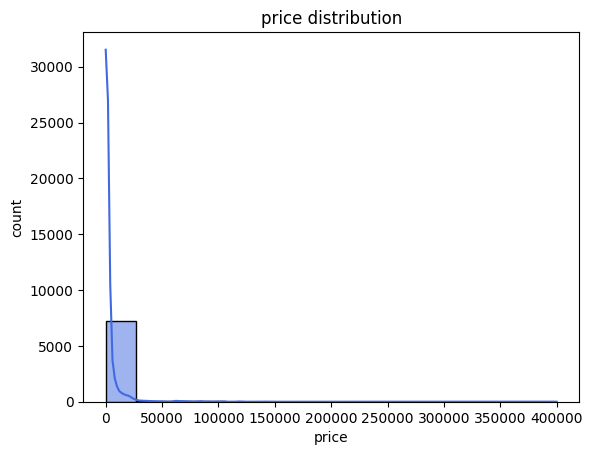

In [143]:
plot.Figure(figsize=(10,10))
sn.histplot(data=df, x="price", bins=15, kde=True, color="royalblue")
plot.title('price distribution')
plot.xlabel("price")
plot.ylabel("count")
plot.show()

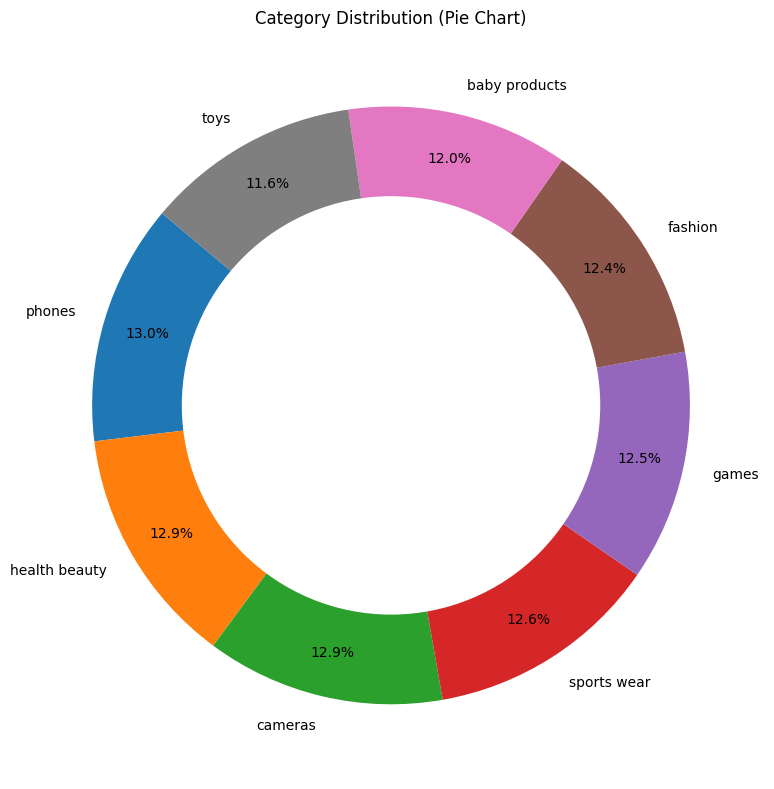

In [144]:

category_counts = df["category_clean"].value_counts()
plot.figure(figsize=(8,8))
plot.pie(
    category_counts.values,
    labels=category_counts.index,
    autopct="%1.1f%%",
    startangle=140,
    pctdistance=0.85
)
centre_circle = plot.Circle((0,0),0.70,fc='white')
fig = plot.gcf()
fig.gca().add_artist(centre_circle)

plot.title("Category Distribution (Pie Chart)")
plot.tight_layout()
plot.show()


C:\Users\KING\AppData\Local\Temp\ipykernel_17652\4107005086.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sn.barplot(


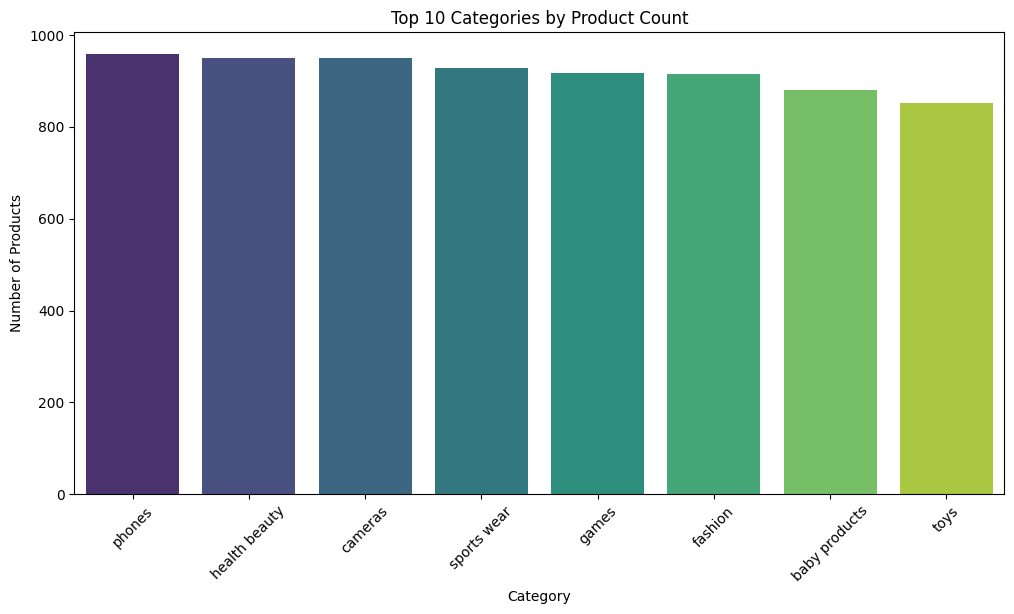

In [145]:
plot.figure(figsize=(12,6))

top10 = df["category_clean"].value_counts().head(10)

sn.barplot(
    x=top10.index,
    y=top10.values,
    palette="viridis"
)

plot.xticks(rotation=45)
plot.title("Top 10 Categories by Product Count")
plot.xlabel("Category")
plot.ylabel("Number of Products")
plot.show()


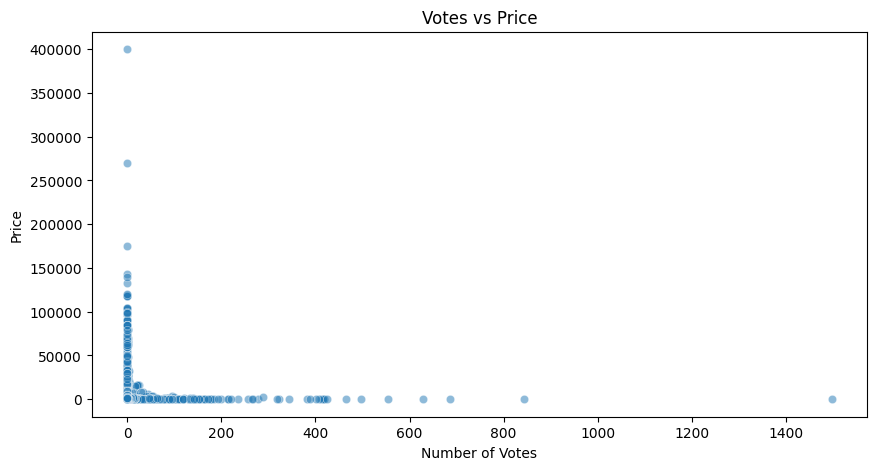

In [164]:
plot.figure(figsize=(10, 5))
sn.scatterplot(data=df, x='numOfVotes', y='price', alpha=0.5)
plot.title("Votes vs Price")
plot.xlabel("Number of Votes")
plot.ylabel("Price")
plot.show()

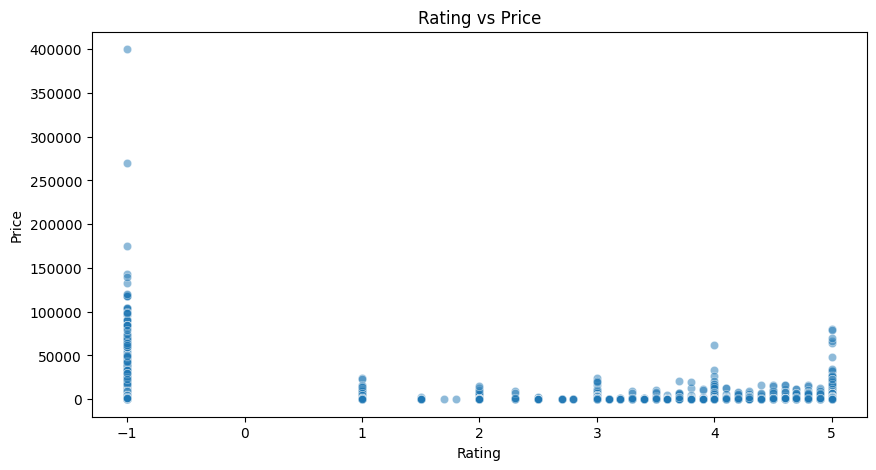

In [165]:
plot.figure(figsize=(10, 5))
sn.scatterplot(data=df, x='rate', y='price', alpha=0.5)
plot.title("Rating vs Price")
plot.xlabel("Rating")
plot.ylabel("Price")
plot.show()

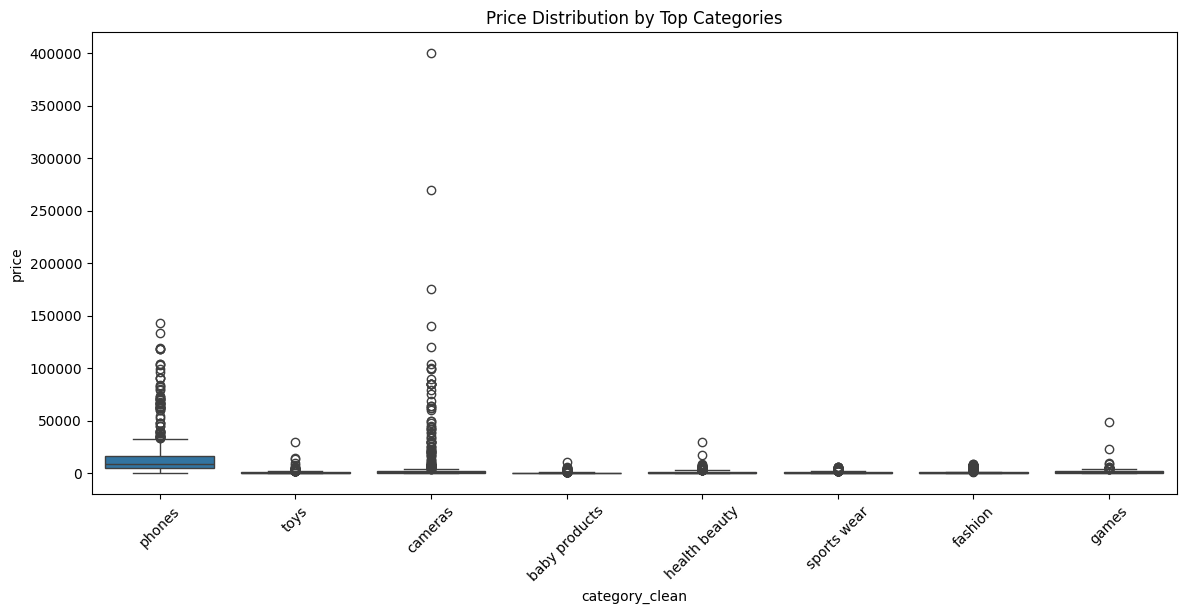

In [167]:
top_cats = df['category_clean'].value_counts().head(10).index
df_top = df[df['category_clean'].isin(top_cats)]

plot.figure(figsize=(14, 6))
sn.boxplot(data=df_top, x='category_clean', y='price')
plot.xticks(rotation=45)
plot.title("Price Distribution by Top Categories")
plot.show()


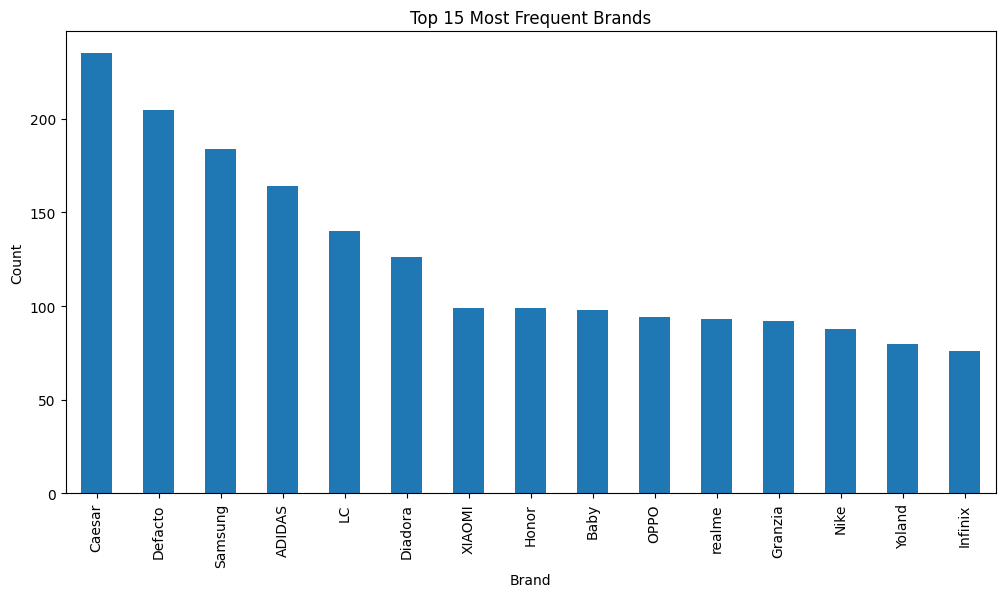

In [ ]:
plot.figure(figsize=(12, 6))
df['brand'].value_counts().head(15).plot(kind='bar')
plot.title("Top 15 Most Frequent Brands")
plot.xlabel("Brand")
plot.ylabel("Count")
plot.show()

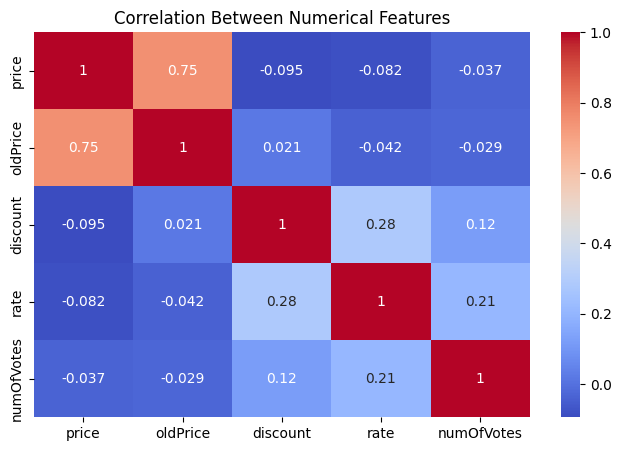

In [169]:
plot.figure(figsize=(8, 5))
sn.heatmap(df.select_dtypes(include="number").corr(), annot=True, cmap="coolwarm")
plot.title("Correlation Between Numerical Features")
plot.show()

## 5- Modeling 

 Price Prediction Model (Random Forest)
This notebook builds a complete predictive model to estimate product prices based on data scraped from Jumia.
##  Why Price Prediction?
Predicting price is the most valuable and meaningful modeling task for this dataset because it allows you to:
- Detect overpriced or underpriced products  
- Complete missing prices automatically  
- Understand what affects price (brand, category, rating, etc.)  
- Support business decisions and pricing analytics  

## Data Preparation
We will:
- Copy the dataset  
- Encode categorical columns  
- Select features and target  


In [150]:
df_model = df.copy()

# Encode categorical features
cat_cols = ["brand", "category_clean", "model", "name_clean"]

for col in cat_cols:
    df_model[col] = df_model[col].astype(str)
    encoder = LabelEncoder()
    df_model[col] = encoder.fit_transform(df_model[col])

# Feature matrix (X) and target variable (y)
X = df_model[["oldPrice", "discount", "rate", "numOfVotes","brand", "category_clean", "model"]]
y = df_model["price"]


## Train–Test Split
We split data into:
- 80% training  
- 20% testing  


In [151]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


## build the Random Forest Model
Random Forest is chosen because:
- It handles non-linear relationships  
- It works well with mixed data  
- It is robust with outliers  
- It performs extremely well for price prediction  


In [152]:
model = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    random_state=42
)

model.fit(X_train, y_train)


,n_estimators,300
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## Model Evaluation
We evaluate using:
- **MAE (Mean Absolute Error)** → lower is better  
- **R² Score** → closer to 1.0 is better  


In [155]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("R² Score:", r2)


Mean Absolute Error: 842.7710235172622
R² Score: 0.6572084509398095


## Feature Importance
This shows which features impact price the most.


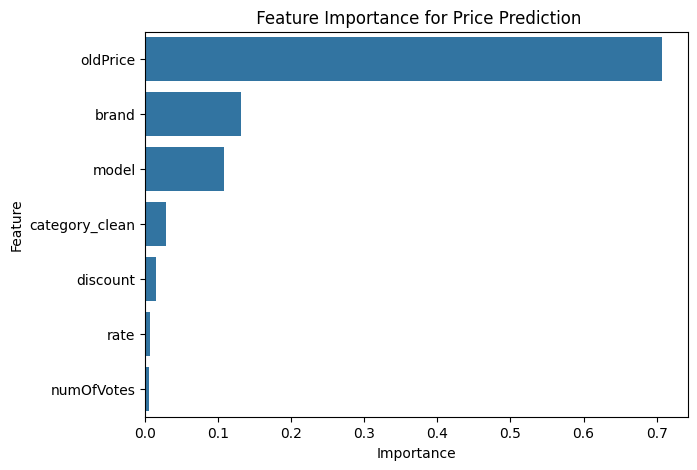

,Feature,Importance
0,oldPrice,0.707345
4,brand,0.131685
6,model,0.108009
5,category_clean,0.028566
1,discount,0.014153
2,rate,0.005785
3,numOfVotes,0.004456


In [157]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values("Importance", ascending=False)

plot.figure(figsize=(7,5))
sn.barplot(data=importance, x="Importance", y="Feature")
plot.title(" Feature Importance for Price Prediction")
plot.show()

importance


## Predict Price for a New Product (Example)
Change the values with any product:
- `[old_price, discount, rate, num_of_votes, brand, category_clean, model]`


In [163]:
example = [[5000, 10, 4.6, 120, 3, 5, 2]]
example_df = pd.DataFrame(example, columns=X.columns)
predicted_price = model.predict(example_df)
print(predicted_price)


[2001.4]


# Final Notes
- This Random Forest model is the **best option** for our dataset  
- we can improve accuracy with:
  - Hyperparameter tuning (GridSearchCV)
  - Better feature engineering
  - Removing outliers  
- Results can be used directly in dashboards (Tableau/PowerBI) or apps  

---
